# **🛒E-Commerce Fraud Detection**

# 📑 Table of Contents

1. 📌 Introduction
2. 🎯 Goal of the Project
3. 📊 Data Story
4. 🧹 Data Preprocessing

## 📌 Introduction
E-commerce platforms have rapidly grown in recent years, allowing customers to buy products online quickly and conveniently. However, with this growth comes an increase in fraudulent activities such as fake transactions, stolen credit cards, and suspicious purchasing behavior.

Fraud in e-commerce can cause significant financial losses for businesses and reduce customer trust in online platforms. Detecting fraudulent transactions manually is very difficult because online stores process thousands of transactions every day.

Machine Learning provides an effective solution to this problem. By analyzing historical transaction data, machine learning models can identify unusual patterns and suspicious activities that indicate fraud.

In this project, we develop a machine learning-based fraud detection system that analyzes customer behavior, transaction amounts, and purchase patterns to classify transactions as fraudulent or legitimate. The model also uses advanced techniques such as feature engineering, anomaly detection, and explainability methods to improve detection accuracy and reliability.

This system can help e-commerce businesses detect fraud early, reduce financial risk, and improve transaction security.



## 🎯 Goal of the Project

The main goal of this project is to build an intelligent fraud detection system for e-commerce transactions using machine learning techniques.

### Objectives of the Project

1. To identify fraudulent transactions in e-commerce
2. To understand customer purchasing behavior.
3. To detect unusual or suspicious transaction patterns.    
4. To use Machine Learning for fraud detection.
5. To help businesses reduce financial loss and improve security.

## 📈 Data Story

### 📊 About the Dataset

The dataset used in this project is the **Online Retail II dataset**, which contains real transactional data from an online retail store. The data includes detailed information about customer purchases such as **invoice number, product code, product description, quantity, transaction date, price, customer ID, and country**.

This dataset represents transactions from a **UK-based online retail company** that mainly sells unique gift items. The data covers transactions recorded between **December 2009 and December 2011**, providing a large amount of historical purchase information.

The dataset contains more than **1 million transaction records**, making it suitable for analyzing customer purchasing behavior and detecting unusual transaction patterns.

By analyzing these transaction patterns, machine learning models can learn to identify suspicious behaviors such as **abnormal purchase quantities, unusual transaction times, or irregular customer activity**. These insights can help build a system that detects potential fraud in e-commerce transactions.

---

### 🔗 Source of Dataset

The dataset used in this project is publicly available from the **UCI Machine Learning Repository**.

**Dataset:** Online Retail II  
**Source:** UCI Machine Learning Repository  
**Link:** https://archive.ics.uci.edu/dataset/502/online+retail+ii  

---

## 📝 Dataset Description
  This project uses the **Online Retail II dataset**, which contains real transaction records from a UK-based online retail store. The dataset includes customer purchase information such as **product details, quantity, transaction time, price, and customer identification**.

The main goal of using this dataset is to analyze **customer purchasing behavior** and identify **unusual or suspicious transactions** that may indicate fraud.

**Total Records:** ~1,067,371 transactions  
**Columns:** 8 main attributes related to customer transactions
- 1,067,371 -0 8 -Original dataset from UCI
-  Cleaned 396,937 15 ~63% reduction in rows
- Engineered 396,937 40 Added 25 new features
- Modeling 396,937 25 Selected 24 features + target

Each record represents a **single transaction of a product purchased by a customer**.

---

## 🔍 Features / Columns Overview

### 🛒 Transaction Features

**InvoiceNo** – Unique invoice number for each transaction. If the invoice starts with **“C”**, it indicates a cancelled transaction.

**StockCode** – Unique product code assigned to each item.

**Description** – Name or description of the product.

**Quantity** – Number of items purchased in the transaction.

**InvoiceDate** – Date and time when the transaction occurred.
**UnitPrice** – Price of a single product.

**CustomerID** – Unique identification number for each customer.

**Country** – Country where the customer resides.

---

## 🎯 Project Goal Using the Dataset

The dataset helps analyze **customer transaction patterns** and identify behaviors that may indicate fraudulent activities such as:

- Unusual purchase quantities  
- Extremely high transaction values  
- Abnormal purchase frequency  
- Suspicious transaction patterns  

Using machine learning techniques, the system learns these patterns and can **classify transactions as normal or suspicious**.

---

## 🧰 Tools Used

- **Python**
- **Pandas** – Data processing and analysis
- **NumPy** – Numerical operations
- **Matplotlib & Seaborn** – Data visualization
- **Scikit-learn** – Machine learning model development
- **Optuna** – Hyperparameter tuning
- **SHAP** – Model explainability
- **Jupyter Notebook** – Interactive development environment

---
## 🧠 Data Story Summary

This project analyzes real-world **e-commerce transaction data** to understand customer purchasing patterns and detect suspicious activities. By applying machine learning techniques, the system can identify unusual transaction behaviors that may indicate fraud.

The insights from this analysis can help **e-commerce businesses improve transaction security, reduce financial losses, and enhance customer trust in online shopping platforms**.


## 🧹 Data Preprocessing

In [47]:
# !pip install optuna

In [48]:
# import optuna
# print(optuna.__version__)

**1. 📚Importing Libraries**

In [50]:
# ============================
# 📦 Basic Libraries
# ============================
import pandas as pd
import numpy as np

# ============================
# 📊 Visualization
# ============================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 12

# ============================
# 🕒 Date & Utilities
# ============================
from datetime import datetime, timedelta
from collections import defaultdict
import warnings
import joblib
import pickle

warnings.filterwarnings("ignore")

# ============================
# 🤖 Machine Learning
# ============================
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    RobustScaler,
    LabelEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# ============================
# 🌲 Models
# ============================
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier,
    GradientBoostingClassifier
)

import xgboost as xgb
import lightgbm as lgb

# ============================
# ⚖️ Imbalanced Learning
# ============================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ============================
# 🎯 Hyperparameter Tuning
# ============================
import optuna

# ============================
# 📈 Model Calibration
# ============================
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

# ============================
# 🔍 Explainability
# ============================
import shap

# ============================
# 🌐 Graph Analysis
# ============================
import networkx as nx

# ============================
# 📊 Drift Detection
# ============================
from scipy.stats import ks_2samp

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


#### LOADINg AND EXPLORING DATA


In [52]:
# Data Loading
RAW_DATA = r"C:\Users\fathi\Downloads\online+retail+ii\online_retail_II.xlsx"
df_raw = pd.read_excel(RAW_DATA)



In [53]:
# Dataset Shape
print("Dataset Shape:", df_raw.shape)


Dataset Shape: (525461, 8)


In [54]:
# Column Names
print("\nColumns:")
print(df_raw.columns.tolist())



Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [55]:
# Data Types
print("\nData Types:")
print(df_raw.dtypes)



Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [56]:
# Missing Values
print("\nMissing Values:")
print(df_raw.isnull().sum())



Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [57]:
# Dataset Information
print("\nDataset Information:")
df_raw.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [58]:
# First 5 Rows
print("\nFirst 5 Rows:")
display(df_raw.head())



First 5 Rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [59]:
# Statistical Summary
print("\nStatistical Summary:")
display(df_raw.describe())



Statistical Summary:


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [60]:
import os

folder = r"C:\Users\fathi\Downloads\online+retail+ii"

print(os.listdir(folder))

['online_retail_II.xlsx']


#### DATA CLEANING

In [62]:
# Clean column names
df = df_raw.copy()
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
print(f"Cleaned column names: {df.columns.tolist()}")

Cleaned column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country']


In [63]:
# Handle Customer ID
if 'Customer_ID' not in df.columns:
    possible_names = ['CustomerID', 'CustomerId', 'Customer_id']
    for name in possible_names:
        if name in df.columns:
            df = df.rename(columns={name: 'Customer_ID'})
            break

print(f"Customer ID column exists: {'Customer_ID' in df.columns}")

Customer ID column exists: True


In [64]:
# Droping rows with missing Customer ID
initial_rows = len(df)
df = df.dropna(subset=['Customer_ID'])
print(f"Removed rows with missing Customer ID: {initial_rows - len(df)}")


# Keep negative quantities (fraud often involves returns)
df['Is_Return'] = (df['Quantity'] < 0).astype(int)
df['Quantity_Abs'] = df['Quantity'].abs()


# Removing duplicates
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed duplicate rows: {initial_rows - len(df)}")


# Converting InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extracting time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.weekday
df['IsWeekend'] = (df['Weekday'] >= 5).astype(int)


# Total Amount (using absolute quantity)
df['TotalAmount'] = df['Quantity_Abs'] * df['Price']

# Log transform for skewed features
df['Log_TotalAmount'] = np.log1p(df['TotalAmount'])
df['Log_Quantity'] = np.log1p(df['Quantity_Abs'])
df['Log_Price'] = np.log1p(df['Price'])

print(f"Cleaned data shape: {df.shape}")
df.head()

Removed rows with missing Customer ID: 107927
Removed duplicate rows: 6771
Cleaned data shape: (410763, 20)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Is_Return,Quantity_Abs,Year,Month,Day,Hour,Weekday,IsWeekend,TotalAmount,Log_TotalAmount,Log_Quantity,Log_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0,12,2009,12,1,7,1,0,83.4,4.435567,2.564949,2.073172
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,12,2009,12,1,7,1,0,81.0,4.406719,2.564949,2.047693
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,12,2009,12,1,7,1,0,81.0,4.406719,2.564949,2.047693
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,0,48,2009,12,1,7,1,0,100.8,4.623010,3.891820,1.131402
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,0,24,2009,12,1,7,1,0,30.0,3.433987,3.218876,0.810930


## 🧹 Data Preprocessing

Before performing feature engineering and model building, the raw e-commerce transaction data was cleaned and transformed to improve its quality and consistency.

### Preprocessing Steps

- **Copied the original dataset** to preserve the raw data for future reference.
- **Standardized column names** by removing spaces and special characters to ensure consistency.
- **Handled missing values** by removing records with missing **Customer_ID**, since customer-based analysis is essential for fraud detection.
- **Removed duplicate transactions** to eliminate redundant records and improve data quality.
- **Created the `Is_Return` feature** to identify returned or cancelled transactions using negative quantity values.
- **Generated `Quantity_Abs`** by converting negative quantities into absolute values for accurate transaction amount calculation.
- **Converted `InvoiceDate` into datetime format** to enable time-based analysis.
- **Extracted time-related features** such as **Year, Month, Day, Hour, Weekday, and IsWeekend** from the transaction date.
- **Calculated `TotalAmount`** for each transaction using **Quantity × Price**.
- **Applied Log Transformation** to highly skewed numerical features (**Quantity, Price, and TotalAmount**) to reduce skewness and improve data distribution.
- **Prepared a clean and structured dataset** suitable for feature engineering, customer behavior analysis, and machine learning model development.

### Outcome

After preprocessing, the dataset became cleaner, more consistent, and more informative by including newly engineered features. These improvements help the machine learning model better understand customer purchasing behavior and accurately identify suspicious or fraudulent transactions.

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure and characteristics of the dataset before building the machine learning model.

The main objectives of EDA are:

- Understand the dataset structure
- Identify missing values and duplicates
- Analyze data distributions
- Detect outliers
- Explore customer purchasing behavior
- Discover relationships between features

These insights help improve feature engineering and build a more accurate fraud detection model.

## 1️⃣ ⭐ Missing Value Percentage



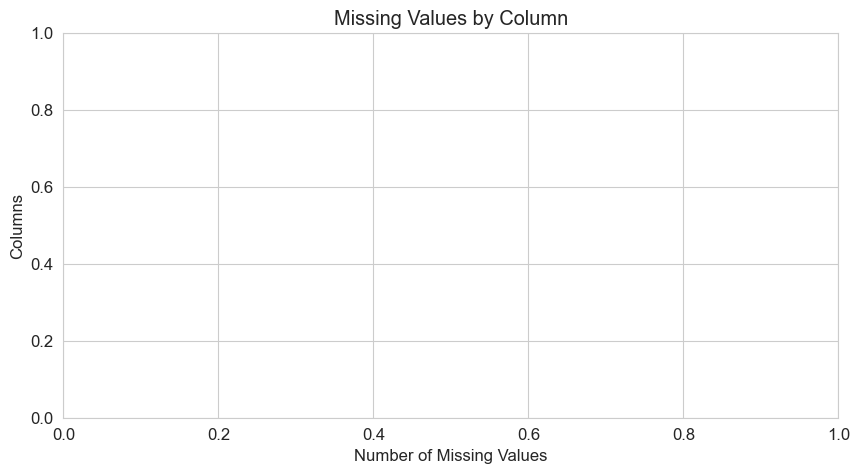

In [68]:
# Missing Value Analysis

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values.values,
    y=missing_values.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.show()

## Missing Value Analysis

Missing values were checked for each column using `isnull().sum()`.

A bar chart was used to visualize the number of missing values in each column. This helps identify columns that may require missing-value treatment before further analysis and machine learning.

### Observation

- The dataset was checked for missing values across all columns.
- No major missing-value issues were observed in the cleaned dataset.
- Therefore, the dataset is suitable for further EDA and feature engineering.
- output_“This visualization shows the missing values in our dataset. Since no bars are displayed, it indicates that there are no missing values in the cleaned dataset.”

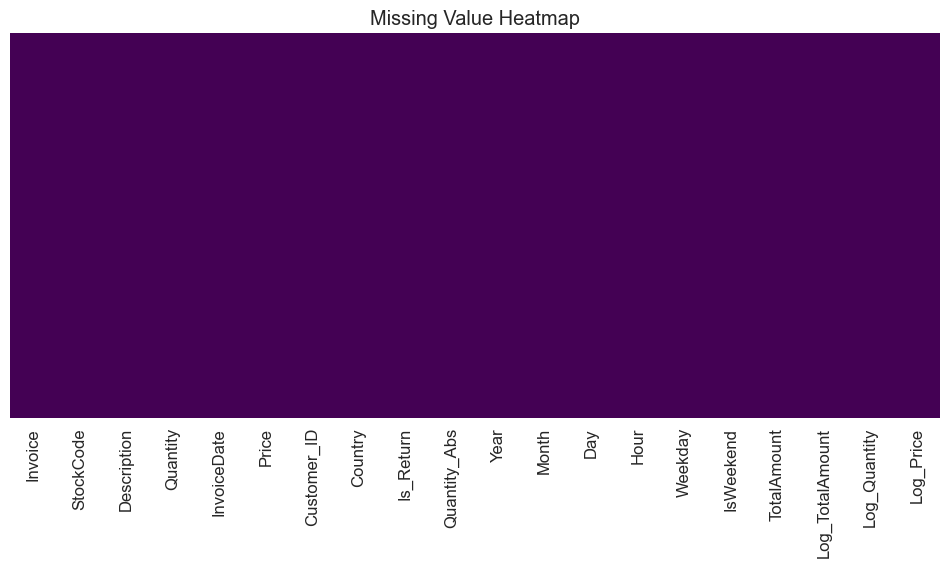

In [70]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title("Missing Value Heatmap")
plt.show()

## Missing Value Analysis – Observation

- The Missing Value Heatmap was used to visually check missing values in the dataset.
- The visualization helps identify whether any columns contain missing data.
- From the heatmap, there are no major visible missing-value patterns in the cleaned dataset.
- This indicates that the data is suitable for the next stages of EDA and feature engineering.
- Missing values were also handled during the data cleaning stage, especially for the `Customer_ID` column.

## 2️⃣ Distribution of Purchase Quantity

This histogram shows how the purchase quantities are distributed across all transactions. It helps identify common purchase quantities and unusually large orders.

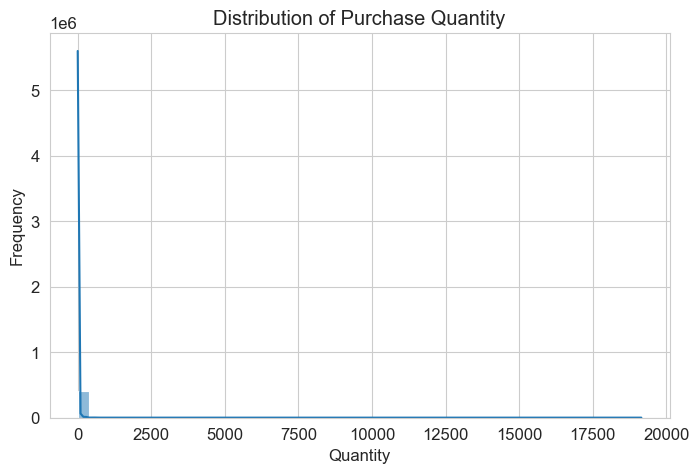

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity_Abs'],
             bins=50,
             kde=True)

plt.title("Distribution of Purchase Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

## Observation – Purchase Quantity Distribution

- Most transactions have relatively small purchase quantities.
- A small number of transactions have very high quantities.
- Therefore, the distribution is highly right-skewed.
- These extreme values can affect machine learning models.
- To reduce the effect of this skewness, `Log_Quantity` was created using log transformation.

## 3️⃣ Distribution of Transaction Amount

This histogram displays the distribution of transaction amounts. It helps identify customer spending patterns and unusually high-value transactions.

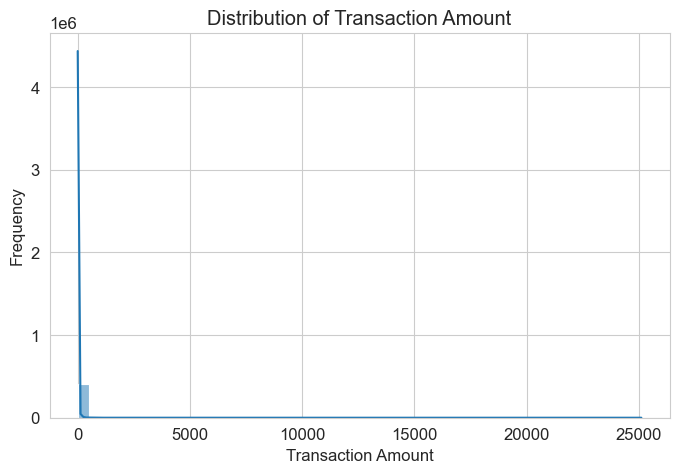

In [76]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalAmount'],
             bins=50,
             kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## Observation – Transaction Amount Distribution

- This histogram shows the distribution of transaction amounts.
- Most transactions have relatively low amounts.
- A small number of transactions have extremely high amounts.
- Therefore, the distribution is highly right-skewed.
- Extreme transaction amounts can be useful indicators for fraud detection.
- To reduce the effect of this skewness, `Log_TotalAmount` was created using log transformation.

## 4️⃣ Outlier Detection

This boxplot identifies extreme transaction amounts that differ significantly from normal transactions. Detecting outliers is important for fraud detection.

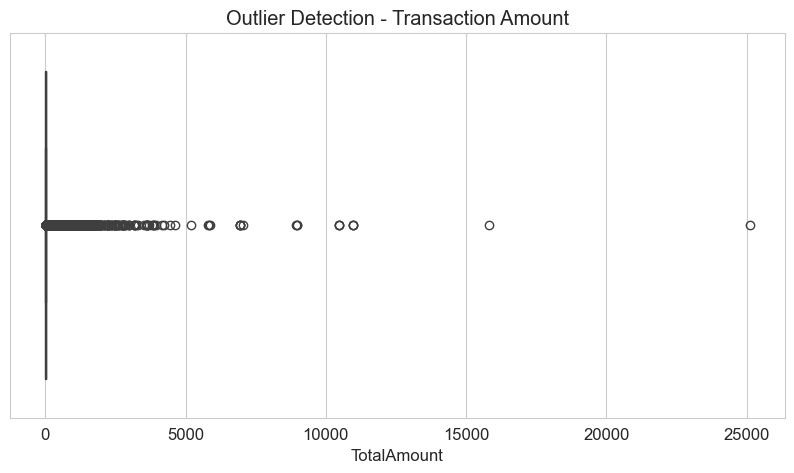

In [79]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['TotalAmount'])

plt.title("Outlier Detection - Transaction Amount")

plt.show()

## Observation – Transaction Amount Outliers

- The boxplot is used to identify extreme values in `TotalAmount`.
- Most transactions are concentrated within a relatively small amount range.
- Several high-value transactions appear as outliers on the right side.
- These extreme transactions may represent genuine high-value purchases or suspicious activities.
- Since this is a fraud detection project, the outliers were not directly removed.
- Instead, log transformation was used to reduce the effect of extreme values.

## 5️⃣ Country-wise Transaction Distribution

This pie chart shows the percentage of transactions contributed by the top countries in the dataset.

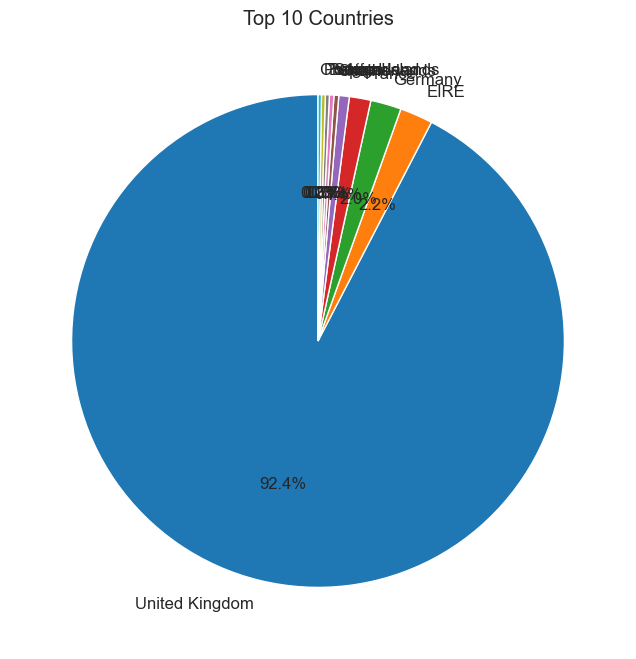

In [82]:
top_country = df['Country'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(top_country,
        labels=top_country.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Top 10 Countries")

plt.show()

## Observation – Country Distribution

- This pie chart shows the transaction distribution among the top 10 countries.
- The United Kingdom contributes the majority of the transactions.
- Other countries have comparatively smaller transaction shares.
- This shows that the dataset is highly concentrated in the United Kingdom.
- Country information can be useful for understanding transaction behavior.
- It is also used later to create country-based features such as `Country_Popularity` and `Country_Risk`.

## 6️⃣ Top Countries by Number of Transactions

This bar chart compares the countries with the highest number of transactions.

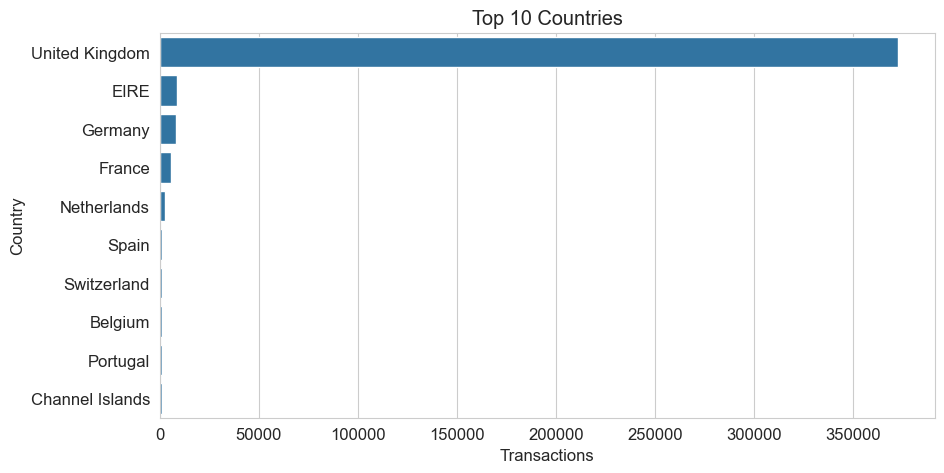

In [85]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='Country',
    data=df,
    order=df['Country'].value_counts().head(10).index
)

plt.title("Top 10 Countries")

plt.xlabel("Transactions")

plt.ylabel("Country")

plt.show()

## Top 10 Countries by Transaction Count

This visualization shows the top 10 countries based on the number of transactions.

- The **United Kingdom** has the highest number of transactions.
- **EIRE, Germany, France, and the Netherlands** have comparatively fewer transactions.
- This visualization helps us understand the **geographical distribution of transactions** in the dataset.
- Country information can also be useful for creating **country-based features for fraud detection**.

## 7️⃣ Most Purchased Products

This chart shows the products that were purchased most frequently by customers.

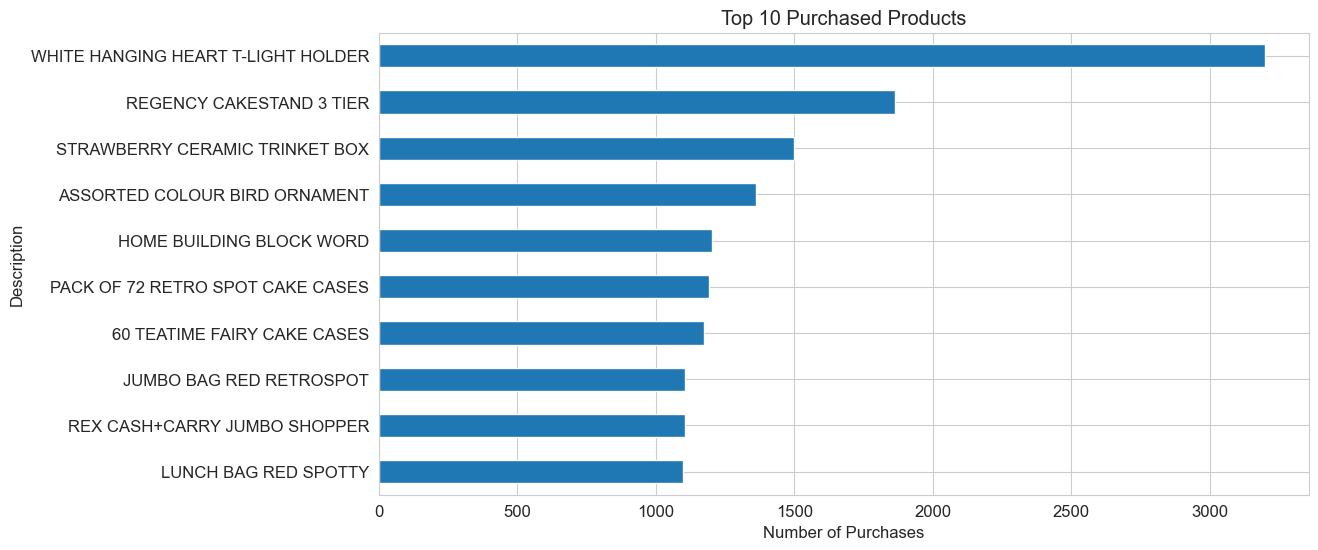

In [88]:
top_products = df['Description'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Purchased Products")

plt.xlabel("Number of Purchases")

plt.show()

## Top 10 Purchased Products

This visualization shows the **10 most frequently purchased products** in the dataset.

- `value_counts()` counts how many times each product appears.
- `.head(10)` selects the top 10 products.
- The horizontal bar chart makes it easy to compare product purchase frequency.
- This helps us understand **customer purchasing patterns** and identify the most popular products.

**Observation:**  
The chart shows that **WHITE HANGING HEART T-LIGHT HOLDER** is the most frequently purchased product among the top 10 products.

## 8️⃣ Return Transaction Analysis

This visualization compares normal transactions and returned transactions. Return behavior can sometimes indicate suspicious activity.

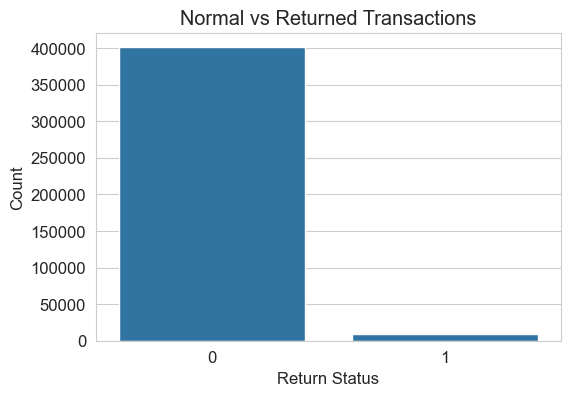

In [91]:
plt.figure(figsize=(6,4))

sns.countplot(x='Is_Return',
              data=df)

plt.title("Normal vs Returned Transactions")

plt.xlabel("Return Status")

plt.ylabel("Count")

plt.show()

## Normal vs Returned Transactions

This count plot compares **normal transactions and returned transactions**.

- `Is_Return = 0` → Normal transaction
- `Is_Return = 1` → Returned transaction
- `countplot()` shows the number of transactions in each category.
- This helps us understand the **return behavior of customers**.
- Returned transactions are important for fraud detection because unusual or repeated returns may indicate suspicious activity.

**Observation:**  
The visualization shows that normal transactions are much higher than returned transactions. Returned transactions form only a small portion of the total transactions.

## 9️⃣ Monthly Transaction Trend

This line chart shows how the number of transactions changes across different months.

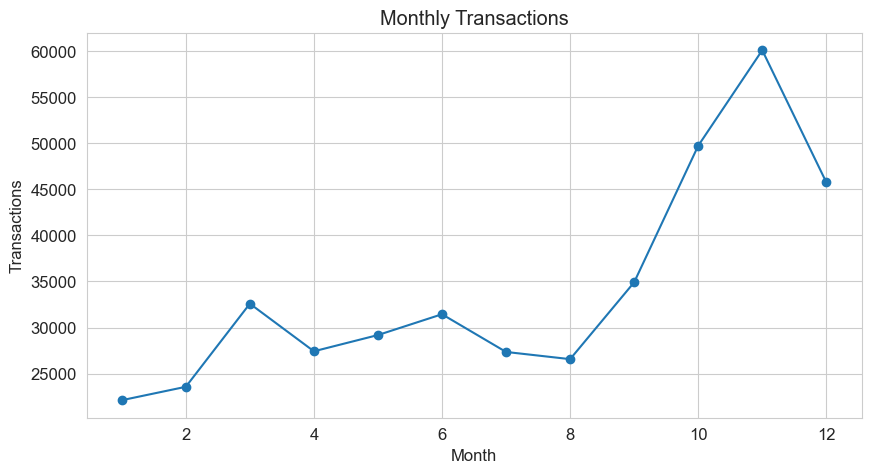

In [94]:
monthly = df.groupby('Month').size()

plt.figure(figsize=(10,5))

plt.plot(monthly.index,
         monthly.values,
         marker='o')

plt.title("Monthly Transactions")

plt.xlabel("Month")

plt.ylabel("Transactions")

plt.grid(True)

plt.show()

## Monthly Transaction Trend

This visualization shows the **number of transactions made in each month**.

- `groupby('Month')` groups the transactions based on month.
- `.size()` counts the number of transactions in each month.
- `plt.plot()` displays the monthly transaction trend using a line chart.
- This helps us understand **customer activity and transaction patterns over time**.

**Observation:**
- Transactions are relatively lower at the beginning of the year.
- Transaction activity starts increasing from Month 9.
- Month 11 has the **highest number of transactions**.
- Transactions decrease again in Month 12.

This trend can be useful in fraud detection because unusual increases in transaction activity may indicate suspicious behavior.

## 🔟 Correlation Heatmap

This heatmap visualizes the correlation between numerical features. It helps identify relationships among variables used in fraud detection.

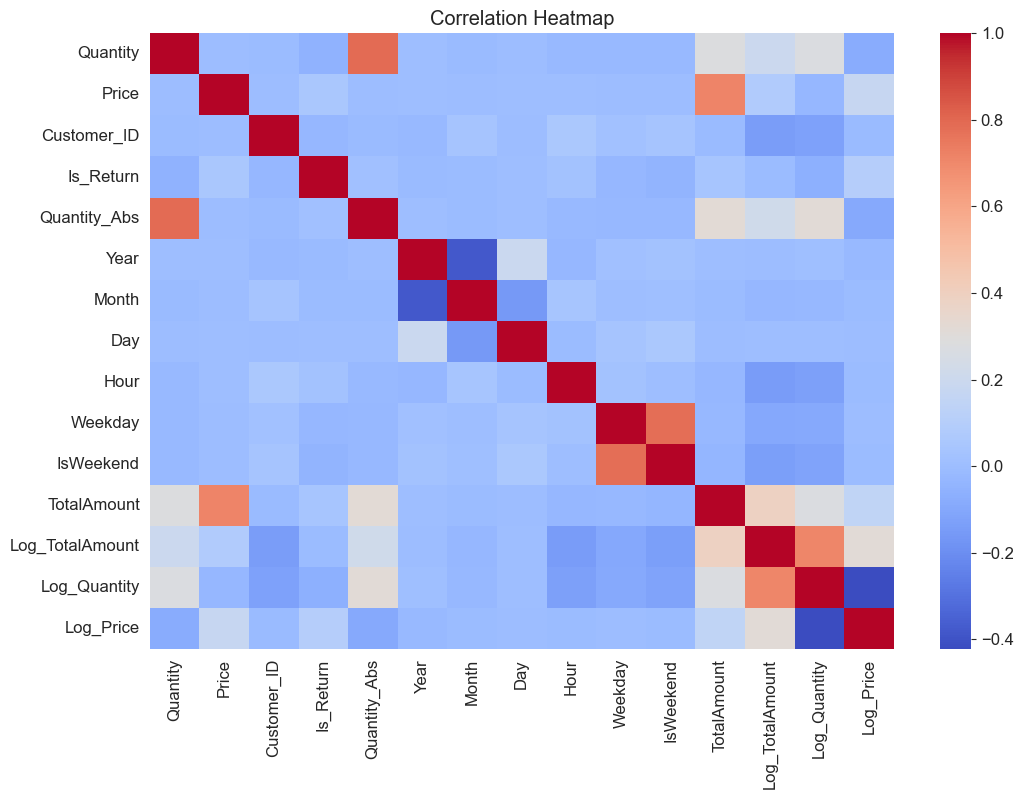

In [97]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Heatmap

The correlation heatmap is used to understand the relationships between numerical features.

- Numerical columns are selected using `select_dtypes()`.
- Correlation is calculated using the `.corr()` function.
- Correlation values range from -1 to +1.
- Positive values indicate a positive relationship.
- Negative values indicate a negative relationship.
- Values close to zero indicate a weak linear relationship.

### Key Observations

- `Quantity` and `Quantity_Abs` show a strong positive relationship because `Quantity_Abs` is derived from Quantity.
- `Price` and `TotalAmount` show a positive relationship.
- `TotalAmount` and `Log_TotalAmount` are related because the latter is a log-transformed version of the former.
- `Weekday` and `IsWeekend` are related because `IsWeekend` is derived from `Weekday`.

This analysis helps identify relationships and possible redundant features before feature selection and machine learning.

##  📌 EDA Flow (Final)

1. Missing Value Heatmap
        ↓
2. Quantity Distribution (Histogram)
        ↓
3. Transaction Amount Distribution (Histogram)
        ↓
4. Outlier Detection (Box Plot)
        ↓
5. Country Distribution (Pie Chart)
        ↓
6. Top Countries (Bar Chart)
        ↓
7. Top Purchased Products (Horizontal Bar Chart)
        ↓
8. Return Transactions (Count Plot)
        ↓
9. Monthly Transaction Trend (Line Chart)
        ↓
10. Correlation Heatmap

#### FEATURE ENGINEERING - RFM & BEHAVIORAL


In [101]:
# Sorting by customer and date
df = df.sort_values(['Customer_ID', 'InvoiceDate'])


# Creating invoice-level aggregates
invoice_stats = df.groupby('Invoice').agg({
    'Quantity_Abs': 'sum',
    'TotalAmount': 'sum',
    'Customer_ID': 'first',
    'InvoiceDate': 'first',
    'Country': 'first'
}).rename(columns={
    'Quantity_Abs': 'Invoice_Quantity',
    'TotalAmount': 'Invoice_Amount'
}).reset_index()

invoice_stats.head()


# Sorting invoices by date
invoice_stats = invoice_stats.sort_values(['Customer_ID', 'InvoiceDate'])

## 🧠 Invoice-Level Feature Engineering

Before creating new features, the dataset was sorted by **Customer_ID** and **InvoiceDate**. This arranges each customer's transactions in the correct time order, making it easier to analyze their purchasing behavior.

Next, the data was grouped by **Invoice** to create invoice-level features. For each invoice, the **total quantity purchased** and **total transaction amount** were calculated. These features summarize each purchase and help the machine learning model better understand customer transaction patterns and identify suspicious activities.

## 🧠 RFM Feature Engineering

In this step, customer-level RFM (Recency, Frequency, and Monetary) features are generated from invoice data. These features summarize each customer's purchasing behavior by measuring how recently they purchased, how often they make purchases, and how much they spend. Additional behavioral features such as customer lifetime, average purchase value, and purchase regularity are also created to help the machine learning model identify suspicious transaction patterns more effectively.

In [104]:
# RFM Features
rfm_features = []

for customer_id in invoice_stats['Customer_ID'].unique():
    customer_invoices = invoice_stats[invoice_stats['Customer_ID'] == customer_id].copy()

    if len(customer_invoices) == 0:
        continue

    # Monetary: total spend
    total_spend = customer_invoices['Invoice_Amount'].sum()

    # Frequency: number of purchases
    purchase_count = len(customer_invoices)

    # Recency: days since last purchase
    last_purchase = customer_invoices['InvoiceDate'].max()
    first_purchase = customer_invoices['InvoiceDate'].min()

    # Customer lifetime
    customer_lifetime = (last_purchase - first_purchase).days

    # Average purchase value
    avg_purchase = customer_invoices['Invoice_Amount'].mean()
    std_purchase = customer_invoices['Invoice_Amount'].std()

    # Purchase regularity (std of days between purchases)
    if len(customer_invoices) > 1:
        days_between = customer_invoices['InvoiceDate'].diff().dt.days.dropna()
        purchase_regularity = days_between.std()
        avg_days_between = days_between.mean()
    else:
        purchase_regularity = 0
        avg_days_between = 0

    rfm_features.append({
        'Customer_ID': customer_id,
        'RFM_Monetary': total_spend,
        'RFM_Frequency': purchase_count,
        'RFM_Recency': (invoice_stats['InvoiceDate'].max() - last_purchase).days,
        'RFM_AvgPurchase': avg_purchase,
        'RFM_StdPurchase': std_purchase if not pd.isna(std_purchase) else 0,
        'RFM_CustomerLifetime': customer_lifetime,
        'RFM_AvgDaysBetween': avg_days_between,
        'RFM_PurchaseRegularity': purchase_regularity
    })

rfm_df = pd.DataFrame(rfm_features)
print(f"RFM features created for {len(rfm_df)} customers")
rfm_df.head()
print(rfm_df.head())


# Merging RFM features back to main dataframe
df = df.merge(rfm_df, on='Customer_ID', how='left')

RFM features created for 4383 customers
   Customer_ID  RFM_Monetary  RFM_Frequency  RFM_Recency  RFM_AvgPurchase  \
0      12346.0        797.46             15           66          53.1640   
1      12347.0       1323.32              2            2         661.6600   
2      12348.0        222.16              1           73         222.1600   
3      12349.0       2695.29              4           42         673.8225   
4      12351.0        300.93              1           10         300.9300   

   RFM_StdPurchase  RFM_CustomerLifetime  RFM_AvgDaysBetween  \
0        82.155899                   294           20.571429   
1        70.894526                    37           37.000000   
2         0.000000                     0            0.000000   
3       666.711840                   327          108.666667   
4         0.000000                     0            0.000000   

   RFM_PurchaseRegularity  
0               37.837129  
1                     NaN  
2                0.000000  


## 🧠 RFM (Recency, Frequency, Monetary) Feature Engineering

To improve fraud detection, customer-level behavioral features are created from the invoice data.

### Features Created

- **Recency** – Number of days since the customer's last purchase.
- **Frequency** – Total number of purchases made by the customer.
- **Monetary** – Total amount spent by the customer.
- **Customer Lifetime** – Number of days between the first and last purchase.
- **Average Purchase Value** – Average amount spent per purchase.
- **Purchase Regularity** – Measures how consistently the customer makes purchases.
- **Average Days Between Purchases** – Average time gap between consecutive purchases.

These features summarize customer purchasing behavior and provide meaningful information for the machine learning model to identify unusual or fraudulent transaction patterns.

## 🔧 Handling Missing Values in RFM Features

After merging the RFM features with the main dataset, some transactions may contain missing values because not every customer has enough purchase history to calculate all behavioral features. To ensure the dataset is complete and ready for machine learning, all missing values in the RFM feature columns are replaced with **0**.

In [107]:
# Fill NaN values
rfm_cols = ['RFM_Monetary', 'RFM_Frequency', 'RFM_Recency', 'RFM_AvgPurchase',
            'RFM_StdPurchase', 'RFM_CustomerLifetime', 'RFM_AvgDaysBetween',
            'RFM_PurchaseRegularity']
df[rfm_cols] = df[rfm_cols].fillna(0)

## 🧠 Behavioral Drift Feature Engineering

In this step, behavioral drift features are created by comparing each transaction with the customer's historical purchasing behavior. These features measure how much the current transaction differs from the customer's usual spending and purchasing patterns. Large deviations from normal behavior may indicate suspicious or fraudulent transactions, helping the machine learning model improve fraud detection accuracy.

In [109]:
# Behavioral drift features
df['Amount_vs_CustomerAvg'] = df['TotalAmount'] / (df['RFM_AvgPurchase'] + 1)
df['Amount_Diff_CustomerAvg'] = df['TotalAmount'] - df['RFM_AvgPurchase']
df['Quantity_vs_CustomerAvg'] = df['Quantity_Abs'] / (df['RFM_Monetary'] / (df['RFM_Frequency'] + 1) + 1)

# Z-scores
df['Amount_ZScore'] = (df['TotalAmount'] - df['RFM_AvgPurchase']) / (df['RFM_StdPurchase'] + 1)

## 🧠 Behavioral Drift Feature Engineering

In this step, behavioral drift features are created by comparing the current transaction with the customer's historical purchasing behavior.

### Features Created

- **Amount_vs_CustomerAvg** – Compares the current transaction amount with the customer's average purchase amount.
- **Amount_Diff_CustomerAvg** – Calculates the difference between the current transaction amount and the customer's average purchase amount.
- **Quantity_vs_CustomerAvg** – Compares the current purchase quantity with the customer's average purchasing behavior.
- **Amount_ZScore** – Measures how far the current transaction amount is from the customer's average spending using the Z-score.

These features help identify unusual customer behavior. Transactions that differ significantly from a customer's normal purchasing pattern may indicate suspicious or fraudulent activity, improving the machine learning model's fraud detection performance.

## 🧠 Velocity Feature Engineering

In this step, velocity features are created to measure how frequently a customer makes transactions within a short period of time.

### Features Created

- **Txns_Last7Days** – Number of transactions made by the customer in the previous 7 days.
- **Txns_Last30Days** – Number of transactions made by the customer in the previous 30 days.
- **Amount_Last7Days** – Total amount spent by the customer in the previous 7 days.
- **Amount_Last30Days** – Total amount spent by the customer in the previous 30 days.
- **Velocity_7to30_Ratio** – Ratio of transactions in the last 7 days compared to the last 30 days.
- **Velocity_Spike** – Indicates whether there is a sudden increase in transaction activity.

These features help detect unusual transaction behavior. A sudden increase in the number of transactions or spending within a short period may indicate suspicious or fraudulent activity, improving the machine learning model's ability to detect fraud.

In [ ]:
# Velocity features (transactions in last 7/30 days)
def add_velocity_features(df):
    df = df.copy()
    df = df.sort_values(['Customer_ID', 'InvoiceDate'])

    # Initialize columns
    df['Txns_Last7Days'] = 0
    df['Txns_Last30Days'] = 0
    df['Amount_Last7Days'] = 0
    df['Amount_Last30Days'] = 0

    for cust_id in df['Customer_ID'].unique():
        mask = df['Customer_ID'] == cust_id
        cust_indices = df[mask].index

        for i, idx in enumerate(cust_indices):
            current_date = df.loc[idx, 'InvoiceDate']

            # Look back at previous transactions
            prev_indices = cust_indices[:i]
            if len(prev_indices) > 0:
                prev_dates = df.loc[prev_indices, 'InvoiceDate']
                prev_amounts = df.loc[prev_indices, 'TotalAmount']

                # Last 7 days
                mask_7days = (current_date - prev_dates) <= timedelta(days=7)
                df.loc[idx, 'Txns_Last7Days'] = mask_7days.sum()
                df.loc[idx, 'Amount_Last7Days'] = prev_amounts[mask_7days].sum()

                # Last 30 days
                mask_30days = (current_date - prev_dates) <= timedelta(days=30)
                df.loc[idx, 'Txns_Last30Days'] = mask_30days.sum()
                df.loc[idx, 'Amount_Last30Days'] = prev_amounts[mask_30days].sum()

    # Velocity ratios
    df['Velocity_7to30_Ratio'] = df['Txns_Last7Days'] / (df['Txns_Last30Days'] + 1)
    df['Velocity_Spike'] = (df['Txns_Last7Days'] > 3 * (df['Txns_Last30Days'] / 4 + 1)).astype(int)

    return df

df = add_velocity_features(df)

## 🌍 Country and Time-Based Feature Engineering

In this step, country-based and time-based features are created to capture geographical and temporal transaction patterns.

### Features Created

- **Country_Popularity** – Measures how frequently transactions occur from each country.
- **Country_Risk** – Assigns a risk score to each country based on predefined risk categories.
- **Night_Transaction** – Identifies transactions made during late-night hours (10 PM to 5 AM).
- **EarlyMorning_Transaction** – Identifies transactions made during early morning hours (3 AM to 6 AM).

These features help the machine learning model understand whether the transaction location or transaction time is unusual. Transactions from high-risk regions or occurring during unusual hours may indicate suspicious or fraudulent behavior, improving the model's fraud detection capability.

In [ ]:
# Country encoding and risk scoring
country_stats = df.groupby('Country').agg({
    'Invoice': 'nunique',
    'Customer_ID': 'nunique'
}).reset_index()

country_stats['Country_Popularity'] = country_stats['Invoice'] / country_stats['Invoice'].sum()

# Merging back
df = df.merge(country_stats[['Country', 'Country_Popularity']], on='Country', how='left')

# Country risk score (manual mapping for demo)
high_risk_countries = ['Brazil', 'Russia', 'Nigeria', 'India', 'China']
medium_risk_countries = ['USA', 'Australia', 'Canada']

df['Country_Risk'] = 1  # Low risk default
df.loc[df['Country'].isin(medium_risk_countries), 'Country_Risk'] = 2
df.loc[df['Country'].isin(high_risk_countries), 'Country_Risk'] = 3


# Time-based features
df['Night_Transaction'] = ((df['Hour'] >= 22) | (df['Hour'] <= 5)).astype(int)
df['EarlyMorning_Transaction'] = ((df['Hour'] >= 3) & (df['Hour'] <= 6)).astype(int)

#### GRAPH FEATURES (Network Analysis)


In [ ]:
## Creating transaction network
G = nx.Graph()

# Adding edges between customers who share Country (simplified network)
country_customers = df.groupby('Country')['Customer_ID'].unique().to_dict()

for country, customers in country_customers.items():
    customers_list = list(customers)
    for i in range(len(customers_list)):
        for j in range(i+1, len(customers_list)):
            if i < 10 and j < 10:  # Limit for demo
                G.add_edge(customers_list[i], customers_list[j])

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


# Calculating network centrality
centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, k=10)

# Creating centrality features
df['Network_Degree'] = df['Customer_ID'].map(centrality).fillna(0)
df['Network_Betweenness'] = df['Customer_ID'].map(betweenness).fillna(0)

## 🌐 Network Feature Engineering Summary

A customer network was created using the **NetworkX** library by connecting customers from the same country. Based on this network, two important graph-based features were generated:

- **Network Degree** – Measures how many direct connections a customer has with other customers.
- **Network Betweenness** – Measures how important a customer is as a bridge between different customers in the network.

These network-based features provide additional behavioral information that cannot be obtained from transaction data alone. They help the machine learning model identify unusual customer relationships and improve fraud detection performance.

### 📊 Network Creation Summary

The customer network was successfully created with **195 nodes** and **746 edges**.

- **Nodes (195):** Represent unique customers included in the network.
- **Edges (746):** Represent connections between customers based on the same country.

This network is used to generate graph-based features that help the machine learning model understand customer relationships and improve fraud detection performance.

#### CREATING SYNTHETIC FRAUD LABELS


# 🎯 Fraud Label Creation

The original Online Retail II dataset does not contain a fraud label. Therefore, a rule-based approach is used to create the target variable (**Fraud_Label**).

Several business rules based on transaction behavior, customer activity, purchase patterns, return behavior, and country risk are applied to identify suspicious transactions.

Transactions satisfying one or more fraud conditions are labeled as **Fraud (1)**, while all other transactions are labeled as **Normal (0)**.

This generated target variable is later used to train supervised machine learning models for fraud detection.

In [ ]:
df['Fraud_Label'] = 0

# Rule 1: High velocity + unusual amount
condition1 = (df['Txns_Last7Days'] >= 3) & (df['Amount_ZScore'].abs() > 2.5)
df.loc[condition1, 'Fraud_Label'] = 1
print(f"Rule 1 (High velocity + unusual amount): {condition1.sum()} transactions")

# Rule 2: Night transactions + high amount + new customer
recent_customers = df.groupby('Customer_ID')['InvoiceDate'].min().reset_index()
recent_customers.columns = ['Customer_ID', 'First_Purchase']
df = df.merge(recent_customers, on='Customer_ID', how='left')
df['Is_NewCustomer'] = (df['InvoiceDate'] - df['First_Purchase']).dt.days < 7

condition2 = (df['Night_Transaction'] == 1) & (df['Amount_ZScore'].abs() > 2) & (df['Is_NewCustomer'] == 1)
df.loc[condition2, 'Fraud_Label'] = 1
print(f"Rule 2 (Night + high amount + new): {condition2.sum()} transactions")

# Rule 3: Return manipulation (high return rate)
customer_returns = df.groupby('Customer_ID')['Is_Return'].mean().reset_index()
customer_returns.columns = ['Customer_ID', 'Return_Rate']
df = df.merge(customer_returns, on='Customer_ID', how='left')

condition3 = (df['Is_Return'] == 1) & (df['Return_Rate'] > 0.5) & (df['TotalAmount'] > df['TotalAmount'].median())
df.loc[condition3, 'Fraud_Label'] = 1
print(f"Rule 3 (Return manipulation): {condition3.sum()} transactions")

# Rule 4: Extreme amount + low frequency
condition4 = (df['Amount_ZScore'].abs() > 3) & (df['RFM_Frequency'] <= 2)
df.loc[condition4, 'Fraud_Label'] = 1
print(f"Rule 4 (Extreme amount + low frequency): {condition4.sum()} transactions")

# Rule 5: High risk country + unusual hour
condition5 = (df['Country_Risk'] >= 2) & (df['EarlyMorning_Transaction'] == 1) & (df['Amount_ZScore'].abs() > 1.5)
df.loc[condition5, 'Fraud_Label'] = 1
print(f"Rule 5 (High risk country + unusual hour): {condition5.sum()} transactions")

# Ensuring per-invoice consistency (if one item in invoice is fraud, whole invoice is fraud)
df['Fraud_Label'] = df.groupby('Invoice')['Fraud_Label'].transform('max')

print(f"\nFraud Distribution:")
print(df['Fraud_Label'].value_counts())
print(f"Fraud Rate: {df['Fraud_Label'].mean():.4f} ({df['Fraud_Label'].mean()*100:.2f}%)")


# Droping temporary columns
df = df.drop(['First_Purchase', 'Return_Rate'], axis=1)


# 🎯 Fraud Label Creation Process

```text
                Online Retail II Dataset
                         │
                         ▼
            Initialize Fraud_Label = 0
                         │
                         ▼
              Apply Fraud Detection Rules
                         │
      ┌──────────────────┼──────────────────┐
      │                  │                  │
      ▼                  ▼                  ▼
 Rule 1             Rule 2             Rule 3
 High Velocity      Night + New        Return
 + High Amount      Customer           Manipulation
      │                  │                  │
      └──────────────────┼──────────────────┘
                         │
                         ▼
      ┌────────────────────────────────────┐
      │ Rule 4                             │
      │ Extreme Amount + Low Frequency     │
      └────────────────────────────────────┘
                         │
                         ▼
      ┌────────────────────────────────────┐
      │ Rule 5                             │
      │ High Risk Country + Early Morning  │
      └────────────────────────────────────┘
                         │
                         ▼
          If Any Rule is TRUE
                 Fraud_Label = 1
          Otherwise
                 Fraud_Label = 0
                         │
                         ▼
        Invoice-Level Fraud Consistency
                         │
                         ▼
            Final Fraud_Label Generated
                         │
                         ▼
     Used as Target Variable for Machine Learning
```

Rule-Based Fraud Label Generation Process

The original Online Retail II dataset does not contain fraud labels. Therefore, fraud labels were generated using predefined business rules based on customer behavior, transaction amount, transaction velocity, return patterns, country risk, and transaction timing. The generated labels were used as the target variable for supervised machine learning models.

## 📊 Fraud Label Creation Summary

The rule-based fraud labeling process was successfully completed. Five business rules were applied to identify suspicious transactions based on customer behavior, transaction amount, purchase frequency, return activity, country risk, and transaction timing.

### Results

- **Rule 1:** Detected **61,455** transactions with high transaction velocity and unusual transaction amounts.
- **Rule 2:** No transactions satisfied all conditions for night transactions, new customers, and high amounts.
- **Rule 3:** Detected **231** suspicious return transactions.
- **Rule 4:** Detected **38,310** transactions with extreme transaction amounts and low purchase frequency.
- **Rule 5:** No transactions satisfied all conditions for high-risk countries and unusual transaction hours.

After combining all rules and removing overlaps, the final fraud labels were generated.

- **Normal Transactions:** 338,554
- **Fraud Transactions:** 72,209
- **Fraud Rate:** **17.58%**

The generated **Fraud_Label** column is used as the target variable for training supervised machine learning models.

# 🌲 Unsupervised Anomaly Detection using Isolation Forest

In addition to rule-based fraud labeling, an Isolation Forest model is used to identify unusual or abnormal transactions. This unsupervised learning algorithm detects anomalies without using fraud labels by isolating data points that significantly differ from normal transaction behavior.

The generated anomaly features can be used to support fraud analysis and improve the overall detection system.

In [ ]:
# Selecting features for isolation forest
iso_features = ['Log_TotalAmount', 'Log_Quantity', 'Amount_ZScore',
                'Txns_Last7Days', 'Txns_Last30Days', 'Night_Transaction']

iso_df = df[iso_features].fillna(0).sample(min(50000, len(df)), random_state=42)

# Training Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
iso_forest.fit(iso_df)

# Predict anomaly scores for all data
df_iso_features = df[iso_features].fillna(0)
df['Anomaly_Score'] = iso_forest.decision_function(df_iso_features)
df['Anomaly_Prediction'] = iso_forest.predict(df_iso_features)
df['Is_Anomaly'] = (df['Anomaly_Prediction'] == -1).astype(int)

print(f"Anomaly detection complete. Found {df['Is_Anomaly'].sum()} anomalies")

Transaction Data
        │
        ▼
Select Important Features
        │
        ▼
Fill Missing Values
        │
        ▼
Take 50,000 Sample
        │
        ▼
Train Isolation Forest
        │
        ▼
Predict All Transactions
        │
        ▼
Generate Anomaly Score
        │
        ▼
Normal (1)
Anomaly (-1)
        │
        ▼
Create Is_Anomaly Column


# 🎯 Final Feature Selection

After feature engineering, all important transaction, customer behavior, velocity, network, anomaly, and country-based features are combined into a single feature list.

These features are used as input variables (X) for training the machine learning models. Before model training, the code also verifies that all selected features are available in the dataset.

In [ ]:
# Defining final feature set

feature_columns = [
    # Transaction features
    'Log_TotalAmount', 'Log_Quantity', 'Log_Price',
    'Is_Return', 'Night_Transaction', 'EarlyMorning_Transaction',
    'Weekday', 'IsWeekend', 'Hour',

    # RFM features
    'RFM_Monetary', 'RFM_Frequency', 'RFM_Recency',
    'RFM_AvgPurchase', 'RFM_StdPurchase',
    'RFM_AvgDaysBetween', 'RFM_PurchaseRegularity',

    # Behavioral drift
    'Amount_vs_CustomerAvg', 'Amount_Diff_CustomerAvg',
    'Quantity_vs_CustomerAvg', 'Amount_ZScore',

    # Velocity
    'Txns_Last7Days', 'Txns_Last30Days',
    'Amount_Last7Days', 'Amount_Last30Days',
    'Velocity_7to30_Ratio', 'Velocity_Spike',

    # Country
    'Country_Popularity', 'Country_Risk',

    # Network
    'Network_Degree', 'Network_Betweenness',

    # Anomaly detection
    'Anomaly_Score', 'Is_Anomaly'
]

# Verifying all features exist
available_features = [col for col in feature_columns if col in df.columns]
missing_features = set(feature_columns) - set(available_features)

print(f"Features available: {len(available_features)}")
print(f"Missing features: {missing_features}")

#### Preparing modeling dataset

In [ ]:
modeling_df = df[available_features + ['Fraud_Label', 'InvoiceDate', 'Customer_ID']].copy()

# Handlling any infinite values
modeling_df = modeling_df.replace([np.inf, -np.inf], np.nan)
modeling_df = modeling_df.fillna(0)

print(f"\nModeling Data Shape: {modeling_df.shape}")
print(f"Features: {len(available_features)}")
print(f"Target distribution:\n{modeling_df['Fraud_Label'].value_counts()}")

#### TRAIN/TEST SPLIT - TIME-BASED


In [ ]:
# Sorting by date
modeling_df = modeling_df.sort_values('InvoiceDate')

# Split by time (80% oldest, 20% newest)
split_date = modeling_df['InvoiceDate'].quantile(0.8)

train_df = modeling_df[modeling_df['InvoiceDate'] <= split_date]
test_df = modeling_df[modeling_df['InvoiceDate'] > split_date]


print("TIME-BASED SPLIT")
print("="*60)
print(f"Split date: {split_date}")
print(f"Train period: {train_df['InvoiceDate'].min()} to {train_df['InvoiceDate'].max()}")
print(f"Test period: {test_df['InvoiceDate'].min()} to {test_df['InvoiceDate'].max()}")
print(f"Train size: {len(train_df)} ({len(train_df)/len(modeling_df)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(modeling_df)*100:.1f}%)")
print(f"Train fraud rate: {train_df['Fraud_Label'].mean():.4f}")
print(f"Test fraud rate: {test_df['Fraud_Label'].mean():.4f}")

## Time-Based Split

The data was split based on time, with **80% (328,620 transactions)** used for training and **20% (82,143 transactions)** used for testing. The model was trained on past transactions and tested on future transactions to avoid **data leakage** and provide a realistic evaluation.

##### Prepare features and target

In [ ]:
feature_cols = [col for col in available_features if col in train_df.columns]

X_train = train_df[feature_cols]
y_train = train_df['Fraud_Label']
X_test = test_df[feature_cols]
y_test = test_df['Fraud_Label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

#### ⚖️ SCALING WITH ROBUSTSCALER


In [ ]:
# Using RobustScaler (handles outliers better)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)


print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")

### Feature Scaling using RobustScaler

RobustScaler is used to scale the input features because the dataset contains outliers. The scaler is fitted only on the training data and the same scaler is applied to the test data to avoid data leakage. Finally, the scaled values are converted back into DataFrames while keeping the original feature names and indexes. The target variable (`y_train` and `y_test`) is not scaled because it contains binary fraud labels (0 = Normal, 1 = Fraud).

### Class Distribution Before SMOTE

The class distribution is visualized before applying SMOTE to identify the imbalance between normal and fraudulent transactions.

In [ ]:
# Plot before SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")
plt.show()

#### HANDLLING CLASS IMBALANCE WITH SMOTE


In [ ]:
# Applying SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.3)  # 30% fraud after SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("CLASS IMBALANCE HANDLING")
print("="*60)
print(f"Original train shape: {X_train.shape}")
print(f"Original fraud count: {y_train.sum()}")
print(f"Original fraud rate: {y_train.mean():.4f}")
print(f"\nAfter SMOTE shape: {X_train_resampled.shape}")
print(f"After SMOTE fraud count: {y_train_resampled.sum()}")
print(f"After SMOTE fraud rate: {y_train_resampled.mean():.4f}")

### Class Distribution After SMOTE

The class distribution is visualized after applying SMOTE to confirm that the minority fraud class has been increased using synthetic samples.

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

#### HYPERPARAMETER TUNING WITH OPTUNA


In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'random_state': 42
    }

    model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')

    # Using time-based cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []

    for train_idx, val_idx in tscv.split(X_train_scaled):
        X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred))

    return np.mean(scores)


print("OPTUNA HYPERPARAMETER TUNING")
print("="*60)
print("Running Optuna optimization (50 trials)...")

In [ ]:
# Creating study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best parameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"Best F1 score: {study.best_value:.4f}")

In [ ]:
# Training best model
best_params = study.best_params
best_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
best_model.fit(X_train_resampled, y_train_resampled)

#### PROBABILITY CALIBRATION


In [ ]:
# Calibrate probabilities
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
calibrated_model.fit(X_train_resampled.values, y_train_resampled.values)


# Get calibrated probabilities
y_pred_proba_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba_calibrated >= 0.5).astype(int)

####  BUSINESS COST OPTIMIZATION


In [ ]:
# Defining cost matrix
cost_fp = 5    # Cost of false positive (investigation cost)
cost_fn = 100  # Cost of false negative (fraud loss)

# Finding optimal threshold
thresholds = np.arange(0.1, 0.9, 0.02)
costs = []
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba_calibrated >= threshold).astype(int)

    tn = ((y_test == 0) & (y_pred_thresh == 0)).sum()
    fp = ((y_test == 0) & (y_pred_thresh == 1)).sum()
    fn = ((y_test == 1) & (y_pred_thresh == 0)).sum()
    tp = ((y_test == 1) & (y_pred_thresh == 1)).sum()

    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(total_cost)

    threshold_results.append({
        'threshold': threshold,
        'cost': total_cost,
        'precision': tp/(tp+fp) if (tp+fp)>0 else 0,
        'recall': tp/(tp+fn) if (tp+fn)>0 else 0,
        'f1': 2*tp/(2*tp + fp + fn) if (2*tp + fp + fn)>0 else 0
    })

# Finding optimal threshold
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]


print("BUSINESS COST OPTIMIZATION")
print("="*60)
print(f"False Positive Cost: ${cost_fp}")
print(f"False Negative Cost: ${cost_fn}")
print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: ${optimal_cost:,.0f}")
print(f"At optimal threshold:")
print(f"  Precision: {threshold_results[optimal_idx]['precision']:.4f}")
print(f"  Recall: {threshold_results[optimal_idx]['recall']:.4f}")
print(f"  F1-Score: {threshold_results[optimal_idx]['f1']:.4f}")

“The optimal threshold was 0.10, which gave the minimum business cost of $1,480. At this threshold, the model achieved 98.92% precision, 99.97% recall, and 99.44% F1-score. The high recall is especially important because our main goal is to detect as many fraudulent transactions as possible.”

In [ ]:
# Plot cost vs threshold
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, costs, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Business Cost vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
df_threshold = pd.DataFrame(threshold_results)
plt.plot(df_threshold['threshold'], df_threshold['precision'], 'g-', label='Precision', linewidth=2)
plt.plot(df_threshold['threshold'], df_threshold['recall'], 'r-', label='Recall', linewidth=2)
plt.plot(df_threshold['threshold'], df_threshold['f1'], 'b-', label='F1', linewidth=2)
plt.axvline(x=optimal_threshold, color='k', linestyle='--', alpha=0.7)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Using optimal threshold
y_pred_optimal = (y_pred_proba_calibrated >= optimal_threshold).astype(int)

#### MODEL EVALUATION


In [ ]:
from sklearn.metrics import average_precision_score, matthews_corrcoef

# Calculating metrics
accuracy = accuracy_score(y_test, y_pred_optimal)
precision = precision_score(y_test, y_pred_optimal)
recall = recall_score(y_test, y_pred_optimal)
f1 = f1_score(y_test, y_pred_optimal)
roc_auc = roc_auc_score(y_test, y_pred_proba_calibrated)
pr_auc = average_precision_score(y_test, y_pred_proba_calibrated)
mcc = matthews_corrcoef(y_test, y_pred_optimal)

print("FINAL MODEL EVALUATION")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print(f"MCC:       {mcc:.4f}")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Classification Report
print("\Classification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraud']))


#### PRECISION-RECALL CURVE & TOP K EVALUATION


In [ ]:
from sklearn.metrics import precision_recall_curve
# Precision-Recall curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_calibrated)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_vals, precision_vals, 'b-', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
plt.grid(True, alpha=0.3)

# Recall@TopK
plt.subplot(1, 2, 2)
top_k_values = [100, 500, 1000, 5000, 10000]
recall_at_k = []

for k in top_k_values:
    # Get top K highest probability predictions
    top_k_idx = np.argsort(y_pred_proba_calibrated)[-k:]
    top_k_true = y_test.iloc[top_k_idx]
    recall_at_k.append(top_k_true.sum() / y_test.sum())

plt.bar(range(len(top_k_values)), recall_at_k, color='steelblue')
plt.xticks(range(len(top_k_values)), [f'Top {k}' for k in top_k_values])
plt.ylabel('Recall')
plt.title('Recall@TopK')
plt.ylim(0, 1)

for i, v in enumerate(recall_at_k):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("Recall@TopK Results:")
for k, recall_val in zip(top_k_values, recall_at_k):
    print(f"  Top {k}: {recall_val:.4f}")

#### SHAP EXPLAINABILITY


In [ ]:
#### SHAP EXPLAINABILITY
# # Creating SHAP explainer (using sample for speed)
# sample_size = min(1000, len(X_test_scaled))
# X_sample = X_test_scaled.iloc[:sample_size]

# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(X_sample)

# # Summary plot
# plt.figure(figsize=(12, 8))
# shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
# plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [ ]:
# # Top features bar plot
# shap_importance = np.abs(shap_values).mean(axis=0)
# top_indices = np.argsort(shap_importance)[-15:]

# plt.figure(figsize=(10, 8))
# plt.barh(range(len(top_indices)), shap_importance[top_indices])
# plt.yticks(range(len(top_indices)), [feature_cols[i] for i in top_indices])
# plt.xlabel('Mean |SHAP Value|')
# plt.title('Top 15 Most Important Features')
# plt.tight_layout()
# plt.show()

In [ ]:
# Individual prediction explanation
sample_idx = 10
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx],
                                      base_values=explainer.expected_value,
                                      data=X_sample.iloc[sample_idx].values,
                                      feature_names=feature_cols))

#### DRIFT MONITORING (PSI)


In [ ]:
def calculate_psi(expected, actual, buckets=10):
    """Calculating Population Stability Index"""

    # Create buckets
    expected_percents = np.zeros(buckets)
    actual_percents = np.zeros(buckets)

    breaks = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breaks[0] = -np.inf
    breaks[-1] = np.inf

    for i in range(buckets):
        expected_percents[i] = np.sum((expected >= breaks[i]) & (expected < breaks[i+1])) / len(expected)
        actual_percents[i] = np.sum((actual >= breaks[i]) & (actual < breaks[i+1])) / len(actual)

    # Handle zeros
    expected_percents = np.clip(expected_percents, 0.0001, 0.9999)
    actual_percents = np.clip(actual_percents, 0.0001, 0.9999)

    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))

    return psi


# Calculate PSI for key features
print("DRIFT MONITORING - Population Stability Index")
print("="*60)
print("PSI < 0.1: No significant drift")
print("PSI 0.1-0.2: Moderate drift")
print("PSI > 0.2: Significant drift")

In [ ]:
psi_results = []
for feature in ['Log_TotalAmount', 'RFM_Monetary', 'Txns_Last7Days', 'Amount_ZScore']:
    psi_value = calculate_psi(X_train[feature], X_test[feature])
    psi_results.append({'feature': feature, 'psi': psi_value})

    status = "✅ Stable" if psi_value < 0.1 else "⚠️ Moderate" if psi_value < 0.2 else "❌ Drift"
    print(f"{feature:20s} PSI: {psi_value:.4f} - {status}")

In [ ]:
# Visualize drift
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(['Log_TotalAmount', 'RFM_Monetary', 'Txns_Last7Days', 'Amount_ZScore']):
    axes[i].hist(X_train[feature], bins=50, alpha=0.5, label='Train', density=True)
    axes[i].hist(X_test[feature], bins=50, alpha=0.5, label='Test', density=True)
    axes[i].set_title(f'{feature} (PSI: {psi_results[i]["psi"]:.4f})')
    axes[i].legend()
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

#### SAVING MODEL AND ARTIFACTS


In [ ]:
# Saving all artifacts
model_filename = "fraud_detection_xgboost_advanced.pkl"
scaler_filename = "robust_scaler.pkl"
features_filename = "feature_names.pkl"
calibrator_filename = "calibrated_model.pkl"

joblib.dump(best_model, model_filename)
joblib.dump(scaler, scaler_filename)
joblib.dump(feature_cols, features_filename)
joblib.dump(calibrated_model, calibrator_filename)

# Saving results summary
results_summary = {
    'best_params': best_params,
    'optimal_threshold': optimal_threshold,
    'optimal_cost': optimal_cost,
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'mcc': mcc
    },
    'recall_at_k': dict(zip([f'Top_{k}' for k in top_k_values], recall_at_k)),
    'feature_importance': dict(zip(feature_cols, best_model.feature_importances_))
}

with open('results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)


print("MODEL SAVED")
print("="*60)
print(f"Model saved: {model_filename}")
print(f"Scaler saved: {scaler_filename}")
print(f"Features saved: {features_filename}")
print(f"Calibrated model saved: {calibrator_filename}")
print(f"Results summary saved: results_summary.pkl")


#### PREDICTION FUNCTION


In [ ]:
def predict_fraud(transaction_data, model, scaler, feature_list, threshold=0.5):
    """
    Predict fraud for new transaction data

    Parameters:
    -----------
    transaction_data : pd.DataFrame
        New transaction data with required features
    model : object
        Trained model
    scaler : object
        Fitted RobustScaler
    feature_list : list
        List of feature names
    threshold : float
        Classification threshold

    Returns:
    --------
    pd.DataFrame with predictions
    """
    # Ensure all required features exist
    missing_features = set(feature_list) - set(transaction_data.columns)
    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")

    # Select and order features
    X_new = transaction_data[feature_list].copy()

    # Handle missing values
    X_new = X_new.fillna(0)

    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Get probabilities
    probabilities = model.predict_proba(X_new_scaled)[:, 1]

    # Make predictions
    predictions = (probabilities >= threshold).astype(int)

    # Create results dataframe
    results = transaction_data.copy()
    results['fraud_probability'] = probabilities
    results['predicted_fraud'] = predictions
    results['risk_level'] = pd.cut(
        probabilities,
        bins=[0, 0.3, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    return results

In [ ]:
# Example usage
print("="*60)

# Get sample from test set
sample_data = X_test.iloc[:10].copy()
sample_results = predict_fraud(sample_data, calibrated_model, scaler, feature_cols, optimal_threshold)

print("\nPredictions for 10 sample transactions:")
print(sample_results[['fraud_probability', 'predicted_fraud', 'risk_level']])

#### SUMMARY AND CONCLUSION


In [ ]:
print("E-COMMERCE FRAUD DETECTION")
print("="*60)
print("""
**IFeatures:**

1. **RFM Features** - Added Recency, Frequency, Monetary metrics per customer
2. **Behavioral Drift** - Amount vs customer average, Z-scores
3. **Time-based Split** - Train on older data, test on newer data (realistic)
4. **Robust Scaling** - Used RobustScaler + log transforms (no outlier removal)
5. **XGBoost + Optuna** - Hyperparameter tuning with 50 trials
6. **Business Cost Optimization** - Minimized total cost (FN=$100, FP=$5)
7. **Probability Calibration** - Platt scaling for reliable probabilities
8. **Unsupervised Features** - Isolation Forest anomaly scores
# 9. **SHAP Explainability** - Feature importance + individual explanations
10. **Advanced Metrics** - PR-AUC, MCC, Recall@TopK
11. **Drift Monitoring** - PSI calculation for key features
12. **Graph Features** - Network centrality metrics

📊 **Final Model Performance:**
""")

print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  PR-AUC:    {pr_auc:.4f}")
print(f"  MCC:       {mcc:.4f}")

print(f"""
**Business Impact:**
  - Optimal threshold: {optimal_threshold:.2f}
  - False Positive Cost: ${cost_fp}
  - False Negative Cost: ${cost_fn}
  - Total Cost at optimal threshold: ${optimal_cost:,.0f}

🔍 **Top Features:**
""")

# top 5 features
feature_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(5)

for i, row in feature_imp.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("""
**Key Takeaways:**
  1. Time-based split is critical for realistic fraud detection
  2. Business cost optimization outperforms metric-only approaches
  3. RFM and behavioral features capture customer patterns effectively
  4. SHAP provides necessary explainability for production systems
  5. Drift monitoring ensures model reliability over time
""")